## **Nodes in LangGraph**

In [1]:
from langgraph.graph import StateGraph, MessagesState, START, END
from typing import TypedDict

class AgentState(TypedDict):
    question: str
    response: str



## **Basics node creations**

In [2]:
def node_1(state: AgentState):
    print("___node___1")

    return {
        "response": "You are in the node 1."
    }

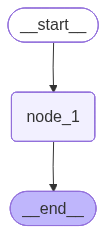

In [3]:
workflow = StateGraph(AgentState)

workflow.add_node("node_1", node_1)

workflow.add_edge(START, "node_1")
workflow.add_edge("node_1", END)

app = workflow.compile()
app

In [4]:
app.invoke(
    {
        "question": "Hi, this is test line..."
    }
)

___node___1


{'question': 'Hi, this is test line...', 'response': 'You are in the node 1.'}

In [5]:
import random
num = random.randint(0, 10)
num

8

## **Conditional node**

In [6]:
def node_2(state: AgentState):
    print("__from node 2__")

    return {
        "response": "Update from node 2."
    }

In [7]:
def node_3(state: AgentState):
    print("__from node 3__")

    return {
        "response": "Update from node 3."
    }

In [8]:
def router(state: AgentState):
    print("__check the conditions__")

    num = random.randint(0, 10)

    if num < 5:
        return "pass"
    else:
        return "filed"

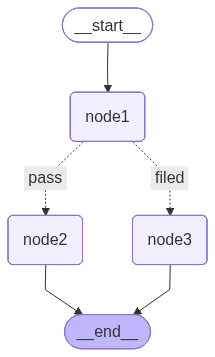

In [9]:
builder = StateGraph(AgentState)

builder.add_node("node1", node_1)
builder.add_node("node2", node_2)
builder.add_node("node3", node_3)

builder.add_edge(START, "node1")
builder.add_conditional_edges(
    "node1",
    router,
    {
        "pass": "node2",
        "filed": "node3"
    }
)
builder.add_edge(["node2", "node3"], END)

my_app = builder.compile()
my_app

In [10]:
my_app.invoke(
    {
        "question": "Hi, this is from conditional graph."
    }
)

___node___1
__check the conditions__
__from node 3__


{'question': 'Hi, this is from conditional graph.',
 'response': 'Update from node 3.'}

## **Parallel Executions**

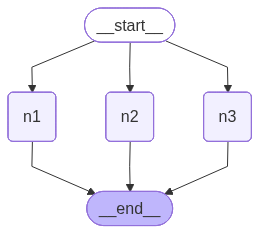

In [16]:
parallel = StateGraph(AgentState)

parallel.add_node("n1", node_1)
parallel.add_node("n2", node_2)
parallel.add_node("n3", node_3)

parallel_node_list = ["n1", "n2", "n3"]

parallel.add_edge(START, "n1")
parallel.add_edge(START, "n2")
parallel.add_edge(START, "n3")
# parallel.add_edge(["n1", "n2", "n3"], END)


app = parallel.compile()
app

In [17]:
app.invoke(
    {
        "question": "Parallel node executions..."
    }
)

___node___1
__from node 2__
__from node 3__


InvalidUpdateError: At key 'response': Can receive only one value per step. Use an Annotated key to handle multiple values.
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_CONCURRENT_GRAPH_UPDATE